In [1]:
import os
import numpy as np
import pandas as pd

import joblib 

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error



In [2]:
df = pd.read_csv('../data/features.csv')
print(f'Dataset shape: {df.shape}')


Dataset shape: (2332, 14)


In [3]:
# Define Features (X) and Target (y)
feature_cols = ['SDI', 'SCD', 'AR', 'LD', 'VRS', 'MATTR', 'PTD', 'PCD', 'ANR', 'PVD']
X = df[feature_cols]
y = df['complexity_score']

In [4]:
# Train/Test Split (85% Train, 15% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [5]:
# Feature Scaling (for SVR)
print("Scaling features")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling features


In [6]:
# Train the Model (SVR with RBF Kernel)
print("Training the SVR Model")
model = SVR(kernel='rbf', C=100, gamma=0.1)
model.fit(X_train_scaled, y_train)

Training the SVR Model


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [7]:
# Evaluate the Model
predictions = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

In [8]:
print("\n--- Final Model Performance ---")
print(f"Mean Absolute Error: {mae:.2f} points")
print(f"R² Score: {r2:.4f}")


--- Final Model Performance ---
Mean Absolute Error: 5.77 points
R² Score: 0.8155


In [9]:
# # Save the Model and Scaler 
# print("\nExporting model and scaler")
# os.makedirs('../backend/models', exist_ok=True)

# joblib.dump(scaler, '../backend/models/scaler.pkl')
# joblib.dump(model, '../backend/models/svr_model.pkl')

# print("SUCCESS! Saved to backend/models/")

In [10]:
# Intializing XGBoost Regressor


xgb_model = xgb.XGBRegressor(
    n_estimators = 300,
    max_depth = 5,
    learning_rate = 0.05,
    random_state = 42
)


In [11]:
# Training model
print("Training XGBoost")
xgb_model.fit(X_train_scaled, y_train)

Training XGBoost


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [12]:
# Test accuracy
y_pred = xgb_model.predict(X_test_scaled)
print('XGBoost R2 Score: ', r2_score(y_test, y_pred))

XGBoost R2 Score:  0.7924271860751874


In [13]:
# # Exporting the model
# joblib.dump(scaler, 'scaler.pkl')
# joblib.dump(xgb_model, 'xgb_model.pkl')

In [14]:
print("\nExporting model and scaler")
os.makedirs('../backend/models', exist_ok=True)

joblib.dump(scaler, '../backend/models/scaler.pkl')
joblib.dump(xgb_model, '../backend/models/xgb_model.pkl')

print("SUCCESS! Saved to backend/models/")


Exporting model and scaler
SUCCESS! Saved to backend/models/


--- WHAT THE BRAIN CARES ABOUT ---
SDI: 30.80%
SCD: 5.86%
AR: 22.85%
LD: 3.70%
VRS: 7.33%
MATTR: 2.39%
PTD: 12.34%
PCD: 3.33%
ANR: 7.68%
PVD: 3.72%


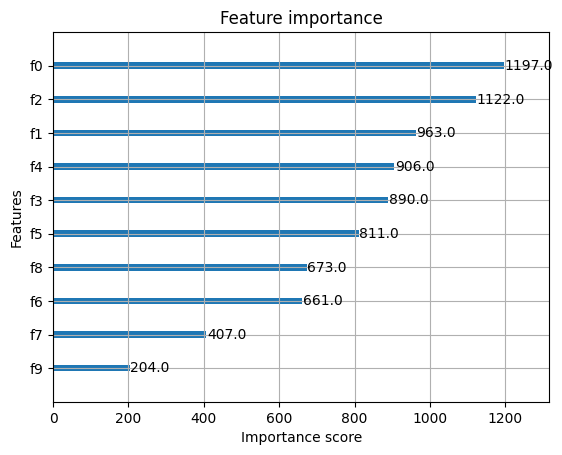

In [15]:
import matplotlib.pyplot as plt

# Get the importance of each feature
importances = xgb_model.feature_importances_

# Print them out
print("--- WHAT THE BRAIN CARES ABOUT ---")
for i, col in enumerate(X.columns):
    print(f"{col}: {importances[i]*100:.2f}%")

# Plot it
xgb.plot_importance(xgb_model)
plt.show()